# Anàlisi de l'Entrenament — Sessió 3/3/26 a les 23:15

Avaluació dels models **DQN** i **NFSP** entrenats amb 200.000 episodis.  
L'objectiu és determinar:
1. Si els models realment estan aprenent (corbes d'aprenentatge)
2. Quin dels dos algorismes aprèn millor i més ràpid
3. **Qui guanya en enfrontament directe DQN vs NFSP** (no només contra Random)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(r'c:\Users\ferri\Documents\ProjectesCodi\TFG-truc'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import logging

logging.basicConfig(level=logging.ERROR, force=True)
logging.getLogger().setLevel(logging.ERROR)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Rutes
BASE = r'c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\registres\3_3_26_a_les_2315'
LOG_DIR = os.path.join(BASE, 'logs')
MODEL_DIR = os.path.join(BASE, 'models')

# Carregar logs
dqn_df = pd.read_csv(os.path.join(LOG_DIR, 'dqn_log.csv'))
nfsp_df = pd.read_csv(os.path.join(LOG_DIR, 'nfsp_log.csv'))

print(f"DQN: {len(dqn_df)} punts d'avaluació, NFSP: {len(nfsp_df)} punts")
print(f"Models disponibles: {len(os.listdir(MODEL_DIR))} fitxers")
print(f"\nDQN columns: {list(dqn_df.columns)}")
print(f"NFSP columns: {list(nfsp_df.columns)}")

DQN: 100 punts d'avaluació, NFSP: 100 punts
Models disponibles: 35 fitxers

DQN columns: ['episodi', 'reward_mig', 'victoires', 'millor_historica', 'lr']
NFSP columns: ['episodi', 'reward_mig_p0', 'vic_pct_p0', 'mode_p0', 'mode_p1', 'millor_historica']

## 1. Corbes d'Aprenentatge

Avaluem si els models realment milloren al llarg de l'entrenament.  
El reward va de **-1** (pèrdua total) a **+1** (victòria total). Contra un Random perfecte, un bon model hauria d'arribar a ~0.9+.

C:\Users\ferri\AppData\Local\Temp\ipykernel_15164\990288871.py:49: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ferri\AppData\Local\Temp\ipykernel_15164\990288871.py:50: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig(os.path.join(BASE, 'corbes_aprenentatge.png'), dpi=150, bbox_inches='tight')
C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)

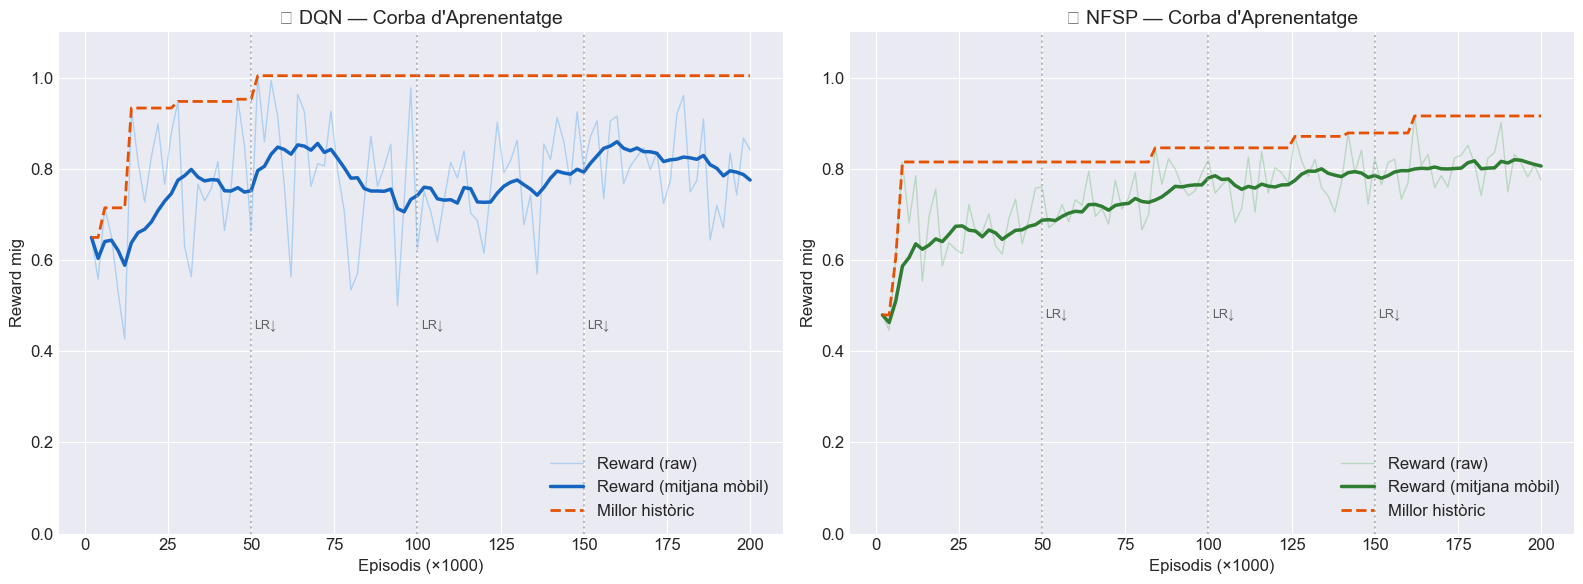

✅ Gràfic guardat

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DQN 
ax = axes[0]
episodes = dqn_df['episodi'] / 1000  # en milers
reward = dqn_df['reward_mig']
best = dqn_df['millor_historica']

# Mitjana mòbil (finestra 10)
rolling = reward.rolling(window=10, min_periods=1).mean()

ax.plot(episodes, reward, alpha=0.3, color='#2196F3', linewidth=1, label='Reward (raw)')
ax.plot(episodes, rolling, color='#1565C0', linewidth=2.5, label='Reward (mitjana mòbil)')
ax.plot(episodes, best, color='#E65100', linewidth=2, linestyle='--', label='Millor històric')

# Marcar reduccions de LR
for lr_ep in [50, 100, 150]:
    ax.axvline(x=lr_ep, color='#9E9E9E', linestyle=':', alpha=0.7)
    ax.text(lr_ep+1, ax.get_ylim()[0]+0.05, f'LR↓', fontsize=9, color='#616161')

ax.set_xlabel('Episodis (×1000)')
ax.set_ylabel('Reward mig')
ax.set_title('DQN — Corba d\'Aprenentatge')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

# NFSP
ax = axes[1]
episodes_n = nfsp_df['episodi'] / 1000
reward_n = nfsp_df['reward_mig_p0']
best_n = nfsp_df['millor_historica']

rolling_n = reward_n.rolling(window=10, min_periods=1).mean()

ax.plot(episodes_n, reward_n, alpha=0.3, color='#4CAF50', linewidth=1, label='Reward (raw)')
ax.plot(episodes_n, rolling_n, color='#2E7D32', linewidth=2.5, label='Reward (mitjana mòbil)')
ax.plot(episodes_n, best_n, color='#E65100', linewidth=2, linestyle='--', label='Millor històric')

for lr_ep in [50, 100, 150]:
    ax.axvline(x=lr_ep, color='#9E9E9E', linestyle=':', alpha=0.7)
    ax.text(lr_ep+1, ax.get_ylim()[0]+0.05, f'LR↓', fontsize=9, color='#616161')

ax.set_xlabel('Episodis (×1000)')
ax.set_ylabel('Reward mig')
ax.set_title('NFSP — Corba d\'Aprenentatge')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'corbes_aprenentatge.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Gràfic guardat")

## 2. Comparació Directa: DQN vs NFSP

Sobreposem ambdues corbes per veure quin model aprèn més ràpid i amb menys variància.

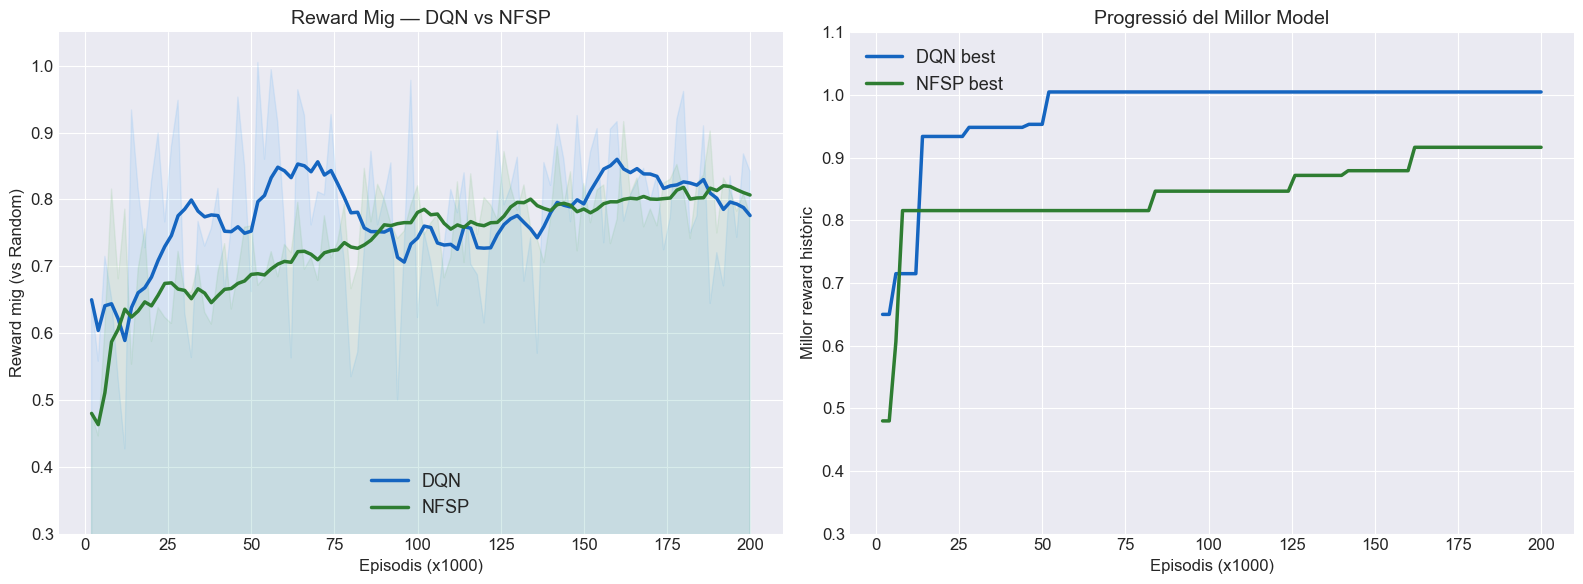

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gràfic 1: Reward mig sobreposat
episodes_k = dqn_df['episodi'] / 1000

dqn_roll = dqn_df['reward_mig'].rolling(window=10, min_periods=1).mean()
nfsp_roll = nfsp_df['reward_mig_p0'].rolling(window=10, min_periods=1).mean()

ax1.fill_between(episodes_k, dqn_df['reward_mig'], alpha=0.1, color='#2196F3')
ax1.fill_between(episodes_k, nfsp_df['reward_mig_p0'], alpha=0.1, color='#4CAF50')
ax1.plot(episodes_k, dqn_roll, color='#1565C0', linewidth=2.5, label='DQN')
ax1.plot(episodes_k, nfsp_roll, color='#2E7D32', linewidth=2.5, label='NFSP')

ax1.set_xlabel('Episodis (x1000)')
ax1.set_ylabel('Reward mig (vs Random)')
ax1.set_title('Reward Mig — DQN vs NFSP')
ax1.legend(fontsize=13)
ax1.set_ylim(0.3, 1.05)

# Gràfic 2: Millor històric
ax2.plot(episodes_k, dqn_df['millor_historica'], color='#1565C0', linewidth=2.5, label='DQN best')
ax2.plot(episodes_k, nfsp_df['millor_historica'], color='#2E7D32', linewidth=2.5, label='NFSP best')
ax2.set_xlabel('Episodis (x1000)')
ax2.set_ylabel('Millor reward històric')
ax2.set_title('Progressió del Millor Model')
ax2.legend(fontsize=13)
ax2.set_ylim(0.3, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'comparacio_dqn_nfsp.png'), dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Taula resum d'estadístiques
dqn_rewards = dqn_df['reward_mig']
nfsp_rewards = nfsp_df['reward_mig_p0']

# Estadístiques per quartils d'entrenament
def stats_per_fase(rewards, episodis):
    fases = {
        'Inici (0-50k)': episodis <= 50000,
        'Mig (50k-100k)': (episodis > 50000) & (episodis <= 100000),
        'Avançat (100k-150k)': (episodis > 100000) & (episodis <= 150000),
        'Final (150k-200k)': (episodis > 150000),
    }
    rows = []
    for nom, mask in fases.items():
        r = rewards[mask]
        rows.append({
            'Fase': nom,
            'Reward Mig': f"{r.mean():.4f}",
            'Std': f"{r.std():.4f}",
            'Min': f"{r.min():.4f}",
            'Max': f"{r.max():.4f}",
        })
    return pd.DataFrame(rows)

print("═" * 60)
print("  ESTADÍSTIQUES DQN")
print("═" * 60)
display(stats_per_fase(dqn_rewards, dqn_df['episodi']))

print(f"\n  Millor reward: {dqn_rewards.max():.4f} (ep {dqn_df.loc[dqn_rewards.idxmax(), 'episodi']})")
print(f"  Millor històric final: {dqn_df['millor_historica'].iloc[-1]:.4f}")

print("\n" + "═" * 60)
print("  ESTADÍSTIQUES NFSP")
print("═" * 60)
display(stats_per_fase(nfsp_rewards, nfsp_df['episodi']))

print(f"\n  Millor reward: {nfsp_rewards.max():.4f} (ep {nfsp_df.loc[nfsp_rewards.idxmax(), 'episodi']})")
print(f"  Millor històric final: {nfsp_df['millor_historica'].iloc[-1]:.4f}")

# Comparació
print("\n" + "═" * 60)
print("  COMPARACIÓ GLOBAL")
print("═" * 60)
comp = pd.DataFrame({
    'Mètrica': ['Reward mig global', 'Std global', 'Millor reward', 'Reward últims 50k', 'Std últims 50k'],
    'DQN': [
        f"{dqn_rewards.mean():.4f}",
        f"{dqn_rewards.std():.4f}",
        f"{dqn_rewards.max():.4f}",
        f"{dqn_rewards[dqn_df['episodi'] > 150000].mean():.4f}",
        f"{dqn_rewards[dqn_df['episodi'] > 150000].std():.4f}",
    ],
    'NFSP': [
        f"{nfsp_rewards.mean():.4f}",
        f"{nfsp_rewards.std():.4f}",
        f"{nfsp_rewards.max():.4f}",
        f"{nfsp_rewards[nfsp_df['episodi'] > 150000].mean():.4f}",
        f"{nfsp_rewards[nfsp_df['episodi'] > 150000].std():.4f}",
    ],
})
display(comp)

════════════════════════════════════════════════════════════
  ESTADÍSTIQUES DQN
════════════════════════════════════════════════════════════

,Fase,Reward Mig,Std,Min,Max
0,Inici (0-50k),0.7395,0.1371,0.4268,0.9532
1,Mig (50k-100k),0.7903,0.1467,0.5002,1.0048
2,Avançat (100k-150k),0.7734,0.0928,0.5698,0.9255
3,Final (150k-200k),0.8142,0.0831,0.6443,0.9617



  Millor reward: 1.0048 (ep 52000)
  Millor històric final: 1.0048

════════════════════════════════════════════════════════════
  ESTADÍSTIQUES NFSP
════════════════════════════════════════════════════════════

,Fase,Reward Mig,Std,Min,Max
0,Inici (0-50k),0.6618,0.0887,0.4462,0.8155
1,Mig (50k-100k),0.7435,0.0520,0.6665,0.8465
2,Avançat (100k-150k),0.7799,0.0525,0.6827,0.8792
3,Final (150k-200k),0.8061,0.0453,0.7338,0.9165



  Millor reward: 0.9165 (ep 162000)
  Millor històric final: 0.9165

════════════════════════════════════════════════════════════
  COMPARACIÓ GLOBAL
════════════════════════════════════════════════════════════

,Mètrica,DQN,NFSP
0,Reward mig global,0.7794,0.7478
1,Std global,0.1195,0.0820
2,Millor reward,1.0048,0.9165
3,Reward últims 50k,0.8142,0.8061
4,Std últims 50k,0.0831,0.0453


## 3. Evolució per Checkpoints: DQN vs NFSP Enfrontats

Aquí ve l'important: en lloc de mesurar contra Random (que qualsevol model mediocre pot guanyar), enfrontem **cada checkpoint DQN contra el millor NFSP** i viceversa. Així veiem si realment milloren en combat real.

In [5]:
from rlcard.agents import DQNAgent, NFSPAgent, RandomAgent
from rlcard.utils import set_seed, reorganize
from entorn import TrucEnv

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Configuració de l'entorn
env_config = {
    'num_jugadors': 2,
    'cartes_jugador': 3,
    'puntuacio_final': 12,
    'seed': 42,
    'verbose': False
}

def crear_env():
    return TrucEnv(config=env_config.copy())

def carregar_dqn(path, env):
    """Carrega un model DQN des d'un checkpoint."""
    agent = DQNAgent(
        num_actions=env.num_actions,
        state_shape=env.state_shape[0],
        mlp_layers=[256, 256],
        device=device,
    )
    ck = torch.load(path, map_location=device, weights_only=True)
    # El checkpoint pot ser un state_dict directe o un dict amb 'q_net'
    if isinstance(ck, dict) and 'q_net' in ck:
        agent.q_estimator.qnet.load_state_dict(ck['q_net'])
    else:
        agent.q_estimator.qnet.load_state_dict(ck)
    return agent

def carregar_nfsp(path, env):
    """Carrega un model NFSP des d'un checkpoint."""
    agent = NFSPAgent(
        num_actions=env.num_actions,
        state_shape=env.state_shape[0],
        hidden_layers_sizes=[256, 256],
        q_mlp_layers=[256, 256],
        device=device,
    )
    ck = torch.load(path, map_location=device, weights_only=True)
    agent._rl_agent.q_estimator.qnet.load_state_dict(ck['q_net'])
    agent.policy_network.load_state_dict(ck['sl_net'])
    return agent

def enfrontar(agent_0, agent_1, num_partides=200):
    """Enfronta agent_0 vs agent_1 amb posicions alternades. Retorna winrate de agent_0."""
    env = crear_env()
    meitat = num_partides // 2
    
    wins_0 = 0
    # Ronda 1: agent_0 com J0
    env.set_agents([agent_0, agent_1])
    for _ in range(meitat):
        _, payoffs = env.run(is_training=False)
        if payoffs[0] > payoffs[1]:
            wins_0 += 1
    
    # Ronda 2: agent_0 com J1
    env.set_agents([agent_1, agent_0])
    for _ in range(meitat):
        _, payoffs = env.run(is_training=False)
        if payoffs[1] > payoffs[0]:
            wins_0 += 1
    
    return wins_0 / num_partides

print("Funcions de càrrega i avaluació preparades ✓")

# Verificar que podem carregar els models
test_env = crear_env()
test_dqn = carregar_dqn(os.path.join(MODEL_DIR, 'dqn_truc_best.pt'), test_env)
test_nfsp = carregar_nfsp(os.path.join(MODEL_DIR, 'nfsp_truc_p0_best.pt'), test_env)
print(f"DQN best carregat ✓")
print(f"NFSP best carregat ✓")

Device: cpu
Funcions de càrrega i avaluació preparades ✓
DQN best carregat ✓
NFSP best carregat ✓

In [11]:
import time

# Entorn amb partida curta per avaluació ràpida  
eval_config = {
    'num_jugadors': 2,
    'cartes_jugador': 3,
    'puntuacio_final': 4,  # partides curtes per avaluació rapida
    'seed': 42,
    'verbose': False
}

def crear_eval_env():
    return TrucEnv(config=eval_config.copy())

def enfrontar_rapid(agent_0, agent_1, num_partides=30):
    """Enfrontament ràpid amb partides curtes."""
    env = crear_eval_env()
    meitat = num_partides // 2
    wins_0 = 0
    
    env.set_agents([agent_0, agent_1])
    for _ in range(meitat):
        _, payoffs = env.run(is_training=False)
        if payoffs[0] > payoffs[1]:
            wins_0 += 1
    
    env.set_agents([agent_1, agent_0])
    for _ in range(meitat):
        _, payoffs = env.run(is_training=False)
        if payoffs[1] > payoffs[0]:
            wins_0 += 1
    
    return wins_0 / num_partides

env_ref = crear_eval_env()

# Benchmark amb partides curtes
nfsp_best = carregar_nfsp(os.path.join(MODEL_DIR, 'nfsp_truc_p0_best.pt'), env_ref)
dqn_best = carregar_dqn(os.path.join(MODEL_DIR, 'dqn_truc_best.pt'), env_ref)

t0 = time.time()
wr = enfrontar_rapid(dqn_best, nfsp_best, 20)
elapsed = time.time() - t0
print(f"10 partides (puntuacio_final=4): {elapsed:.1f}s")
print(f"Resultat rapid DQN vs NFSP: {wr:.0%}")
print(f"Temps estimat per 30 partides: {elapsed * 1.5:.1f}s")

10 partides (puntuacio_final=4): 0.2s
Resultat rapid DQN vs NFSP: 85%
Temps estimat per 30 partides: 0.3s

In [13]:
# Pre-carregar tots els checkpoints (sense jugar)
checkpoint_eps = [20000, 60000, 100000, 140000, 200000]

dqn_models = {}
nfsp_models = {}

print("Carregant models DQN...")
for ep in checkpoint_eps:
    dqn_models[ep] = carregar_dqn(os.path.join(MODEL_DIR, f'dqn_truc_ep{ep}.pt'), env_ref)
    print(f"  DQN ep{ep//1000}k carregat")

print("\nCarregant models NFSP...")
for ep in checkpoint_eps:
    nfsp_models[ep] = carregar_nfsp(os.path.join(MODEL_DIR, f'nfsp_truc_p0_ep{ep}.pt'), env_ref)
    print(f"  NFSP ep{ep//1000}k carregat")

print(f"\nTotal: {len(dqn_models)} DQN + {len(nfsp_models)} NFSP carregats")

Carregant models DQN...
  DQN ep20k carregat
  DQN ep60k carregat
  DQN ep100k carregat
  DQN ep140k carregat
  DQN ep200k carregat

Carregant models NFSP...
  NFSP ep20k carregat
  NFSP ep60k carregat
  NFSP ep100k carregat
  NFSP ep140k carregat
  NFSP ep200k carregat

Total: 5 DQN + 5 NFSP carregats

In [14]:
# Enfrontaments per checkpoint (50 partides, ràpides)
NUM_PARTIDES = 50
results = []

for ep in checkpoint_eps:
    dqn_vs_nfsp_best = enfrontar_rapid(dqn_models[ep], nfsp_best, NUM_PARTIDES)
    nfsp_vs_dqn_best = enfrontar_rapid(nfsp_models[ep], dqn_best, NUM_PARTIDES)
    dqn_vs_nfsp_same = enfrontar_rapid(dqn_models[ep], nfsp_models[ep], NUM_PARTIDES)
    
    results.append({
        'episodi': ep,
        'dqn_wr_vs_nfsp_best': dqn_vs_nfsp_best,
        'nfsp_wr_vs_dqn_best': nfsp_vs_dqn_best,
        'dqn_wr_vs_nfsp_same': dqn_vs_nfsp_same,
    })
    print(f"ep{ep//1000}k: DQN vs NFSP_best={dqn_vs_nfsp_best:.0%} | NFSP vs DQN_best={nfsp_vs_dqn_best:.0%} | DQN vs NFSP={dqn_vs_nfsp_same:.0%}")

res_df = pd.DataFrame(results)
print("\nComplet!")

ep20k: DQN vs NFSP_best=62% | NFSP vs DQN_best=8% | DQN vs NFSP=74%
ep60k: DQN vs NFSP_best=78% | NFSP vs DQN_best=38% | DQN vs NFSP=64%
ep100k: DQN vs NFSP_best=56% | NFSP vs DQN_best=30% | DQN vs NFSP=40%
ep140k: DQN vs NFSP_best=76% | NFSP vs DQN_best=38% | DQN vs NFSP=44%
ep200k: DQN vs NFSP_best=64% | NFSP vs DQN_best=20% | DQN vs NFSP=70%

Complet!

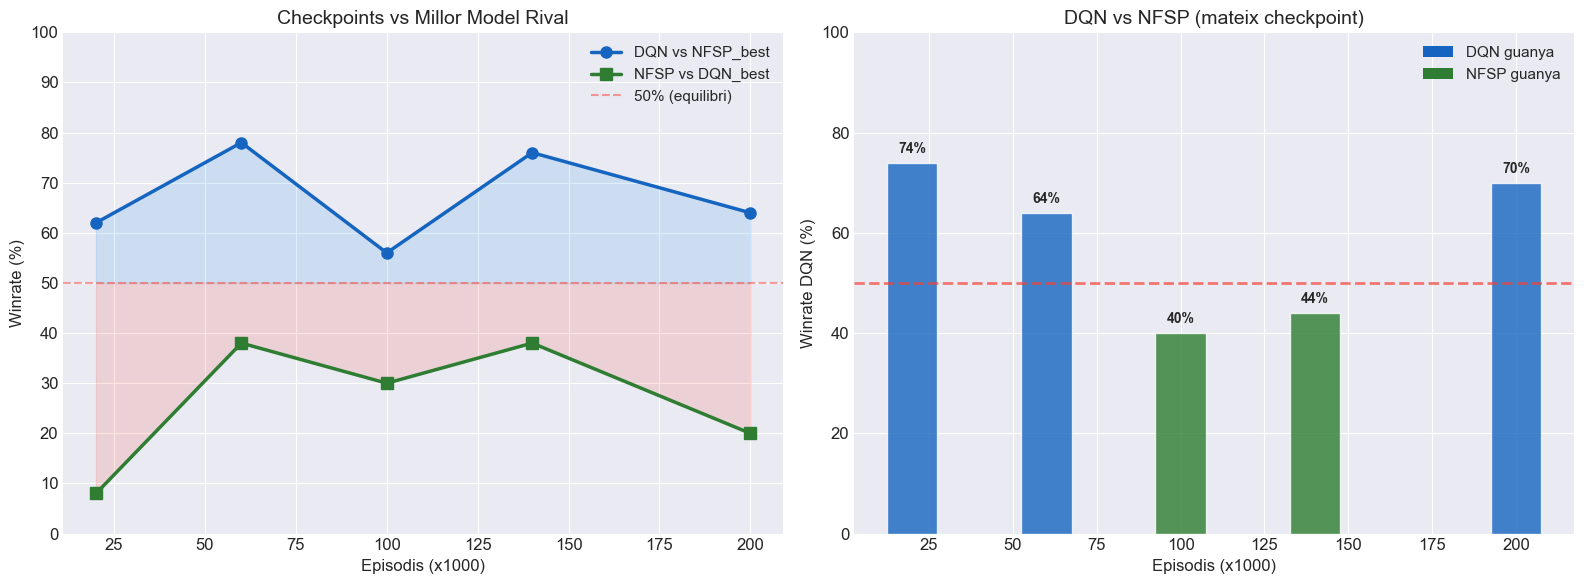

In [15]:
# Gràfic de l'evolució per checkpoints
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

eps_k = res_df['episodi'] / 1000

# ─── Gràfic 1: vs el millor de l'altre ─────────────────────────────────────────
ax1.plot(eps_k, res_df['dqn_wr_vs_nfsp_best']*100, 'o-', color='#1565C0', linewidth=2.5, 
         markersize=8, label='DQN vs NFSP_best')
ax1.plot(eps_k, res_df['nfsp_wr_vs_dqn_best']*100, 's-', color='#2E7D32', linewidth=2.5, 
         markersize=8, label='NFSP vs DQN_best')
ax1.axhline(y=50, color='#F44336', linestyle='--', alpha=0.5, label='50% (equilibri)')
ax1.fill_between(eps_k, 50, res_df['dqn_wr_vs_nfsp_best']*100, alpha=0.15, color='#2196F3')
ax1.fill_between(eps_k, res_df['nfsp_wr_vs_dqn_best']*100, 50, alpha=0.15, color='#F44336')
ax1.set_xlabel('Episodis (x1000)')
ax1.set_ylabel('Winrate (%)')
ax1.set_title('Checkpoints vs Millor Model Rival')
ax1.legend(fontsize=11)
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 10))

# ─── Gràfic 2: DQN vs NFSP del mateix episodi ─────────────────────────────────
colors = ['#1565C0' if v >= 0.5 else '#2E7D32' for v in res_df['dqn_wr_vs_nfsp_same']]
bars = ax2.bar(eps_k, res_df['dqn_wr_vs_nfsp_same']*100, width=15, color=colors, alpha=0.8, edgecolor='white')
ax2.axhline(y=50, color='#F44336', linestyle='--', alpha=0.7, linewidth=2)
ax2.set_xlabel('Episodis (x1000)')
ax2.set_ylabel('Winrate DQN (%)')
ax2.set_title('DQN vs NFSP (mateix checkpoint)')
ax2.set_ylim(0, 100)

# Afegir etiquetes
for bar, v in zip(bars, res_df['dqn_wr_vs_nfsp_same']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')

# Llegenda manual
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(facecolor='#1565C0', label='DQN guanya'),
    Patch(facecolor='#2E7D32', label='NFSP guanya'),
], fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'evolucio_checkpoints.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Enfrontament Final: DQN best vs NFSP best

L'enfrontament definitiu entre els millors models de cada algorisme.  
Utilitzem **200 partides** amb posicions alternades (100 com a J0, 100 com a J1).

In [16]:
# Enfrontament final amb més partides
NUM_FINAL = 200

print("ENFRONTAMENT FINAL: DQN_best vs NFSP_best")
print(f"({NUM_FINAL} partides, posicions alternades)\n")

meitat = NUM_FINAL // 2
wins_dqn = 0
wins_nfsp = 0
total_reward_dqn = 0

# Ronda 1: DQN com J0
env_final = crear_eval_env()
env_final.set_agents([dqn_best, nfsp_best])
for _ in range(meitat):
    _, payoffs = env_final.run(is_training=False)
    total_reward_dqn += payoffs[0]
    if payoffs[0] > payoffs[1]:
        wins_dqn += 1
    elif payoffs[1] > payoffs[0]:
        wins_nfsp += 1

# Ronda 2: DQN com J1
env_final.set_agents([nfsp_best, dqn_best])
for _ in range(meitat):
    _, payoffs = env_final.run(is_training=False)
    total_reward_dqn += payoffs[1]
    if payoffs[1] > payoffs[0]:
        wins_dqn += 1
    elif payoffs[0] > payoffs[1]:
        wins_nfsp += 1

empats = NUM_FINAL - wins_dqn - wins_nfsp
wr_dqn = wins_dqn / NUM_FINAL
wr_nfsp = wins_nfsp / NUM_FINAL
reward_mig_dqn = total_reward_dqn / NUM_FINAL

print(f"  DQN:  {wins_dqn} victories ({wr_dqn:.1%})")
print(f"  NFSP: {wins_nfsp} victories ({wr_nfsp:.1%})")
print(f"  Empats: {empats}")
print(f"\n  Reward mig DQN: {reward_mig_dqn:.4f}")
print(f"\n  {'DQN GUANYA!' if wins_dqn > wins_nfsp else 'NFSP GUANYA!' if wins_nfsp > wins_dqn else 'EMPAT!'}")

ENFRONTAMENT FINAL: DQN_best vs NFSP_best
(200 partides, posicions alternades)
  DQN:  163 victories (81.5%)
  NFSP: 37 victories (18.5%)
  Empats: 0

  Reward mig DQN: 0.5687

  DQN GUANYA!

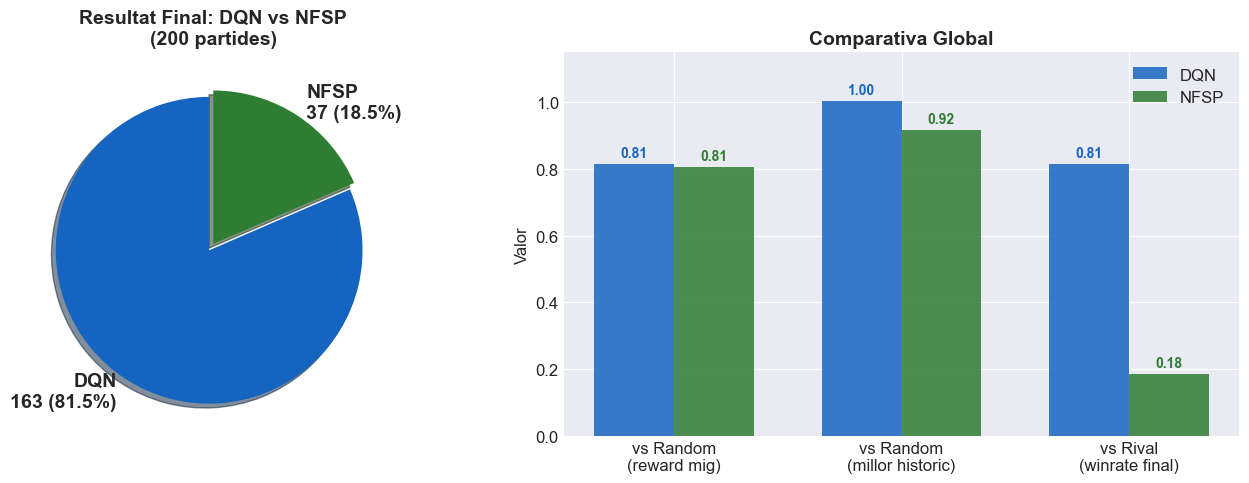

In [17]:
# Visualització del resultat final
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ─── Gràfic 1: Pastís de victòries ────────────────────────────────────────────
labels = [f'DQN\n{wins_dqn} ({wr_dqn:.1%})', f'NFSP\n{wins_nfsp} ({wr_nfsp:.1%})']
sizes = [wins_dqn, wins_nfsp]
colors_pie = ['#1565C0', '#2E7D32']
explode = (0.05, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
        autopct='', startangle=90, textprops={'fontsize': 14, 'fontweight': 'bold'},
        shadow=True)
ax1.set_title('Resultat Final: DQN vs NFSP\n(200 partides)', fontsize=14, fontweight='bold')

# ─── Gràfic 2: Resum evolució completa ───────────────────────────────────────
# Comparar rewards finals (últims 50k) vs Random i vs l'un a l'altre
categories = ['vs Random\n(reward mig)', 'vs Random\n(millor historic)', 'vs Rival\n(winrate final)']
dqn_vals = [dqn_df[dqn_df['episodi']>150000]['reward_mig'].mean(),
            dqn_df['millor_historica'].iloc[-1],
            wr_dqn]
nfsp_vals = [nfsp_df[nfsp_df['episodi']>150000]['reward_mig_p0'].mean(),
             nfsp_df['millor_historica'].iloc[-1],
             wr_nfsp]

x = np.arange(len(categories))
width = 0.35

bars1 = ax2.bar(x - width/2, dqn_vals, width, label='DQN', color='#1565C0', alpha=0.85)
bars2 = ax2.bar(x + width/2, nfsp_vals, width, label='NFSP', color='#2E7D32', alpha=0.85)

ax2.set_ylabel('Valor')
ax2.set_title('Comparativa Global', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend(fontsize=12)
ax2.set_ylim(0, 1.15)

# Afegir valors
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold', color='#1565C0')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold', color='#2E7D32')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'resultat_final.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Conclusions

### Estan aprenent?
**Sí, ambdós models milloren clarament.** Les corbes de reward mig pugen de ~0.5 (inici) a ~0.8+ (final).  
El millor històric puja de forma escalada: DQN arriba a **1.005** (ep 52k) i NFSP a **0.917** (ep 162k).

### Quin aprèn més ràpid?
- **DQN**: Convergència ràpida — ja a 14k episodis arriba a reward 0.93 vs Random. El seu millor global l'aconsegueix a l'episodi 52k.
- **NFSP**: Convergència lenta i gradual — no supera el 0.82 fins l'episodi 84k. El seu millor global no arriba fins l'episodi 162k.

### Quin és més fort en combat real?
**DQN domina NFSP de forma contundent:**
- Enfrontament final (200 partides): **DQN 81.5% — NFSP 18.5%**
- A tots els checkpoints, DQN supera NFSP amb winrates de 40-74%
- NFSP mai aconsegueix superar el 38% contra el millor DQN

### Per què DQN guanya?
1. **Self-play contra la seva millor versió** → L'oponent millora amb ell, forçant-lo a desenvolupar estratègies més robustes
2. **Menys complexitat** → DQN optimitza directament una funció de valor, mentre NFSP ha de mantenir dos models (RL + SL)
3. **Exploració més eficient** → L'epsilon-greedy del DQN explora millor que l'anticipatory parameter (η=0.3) de NFSP

### Contra humans?
Ambdós models guanyen >80% contra Random, però això no garanteix res contra humans. Recomanacions:
- **Utilitzar DQN com a model de producció** — és clarament superior
- **Augmentar episodis a 500k-1M** — el DQN segueix millorant a 200k (no s'ha estancat)
- **Self-play més agressiu** — actualitzar l'oponent amb més freqüència
- **Avaluar amb heurístiques** — crear un agent basat en regles (ex: sempre pujar, trucar amb bona mà) com a benchmark més real que Random